In [15]:
import argparse
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from arch import arch_model


def huber_loss(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return 0.5 * quad**2 + delta * lin


def compute_metrics(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    mse = np.mean(err ** 2)
    rmse = math.sqrt(mse)
    mae = np.mean(np.abs(err))
    huber = np.mean(huber_loss(y_true, y_pred, delta=delta))
    sign_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    return {
        "n": int(len(y_true)),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "huber": float(huber),
        "sign_accuracy": float(sign_acc),
    }


def one_step_garch_forecast(series, warmup=256, mean_type="AR", p=1, q=1, dist="normal"):
    """
    Expanding-window one-step-ahead forecasts for one return series.

    series: pd.Series indexed by date
    returns:
      pred_df with columns [date, y_true, y_pred]
    """
    s = pd.Series(series).dropna().astype(float)
    if len(s) <= warmup + 1:
        return pd.DataFrame(columns=["date", "y_true", "y_pred"])

    dates = []
    y_true = []
    y_pred = []

    values = s.values
    idx = s.index

    # arch often behaves better if returns are scaled from ~0.01 to ~1
    scale = 100.0
    scaled_values = values * scale

    for t in range(warmup, len(s) - 1):
        train = scaled_values[:t]

        try:
            if mean_type.upper() == "AR":
                am = arch_model(
                    train,
                    mean="AR",
                    lags=1,
                    vol="GARCH",
                    p=p,
                    q=q,
                    dist=dist,
                    rescale=False,
                )
            else:
                am = arch_model(
                    train,
                    mean="Constant",
                    vol="GARCH",
                    p=p,
                    q=q,
                    dist=dist,
                    rescale=False,
                )

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = am.fit(disp="off", show_warning=False)

            fcast = res.forecast(horizon=1, reindex=False)

            # mean forecast for next step
            pred_scaled = float(fcast.mean.values[-1, 0])
            pred = pred_scaled / scale

            dates.append(idx[t + 1])
            y_true.append(values[t + 1])
            y_pred.append(pred)

        except Exception:
            # skip unstable fits
            continue

    return pd.DataFrame({
        "date": dates,
        "y_true": y_true,
        "y_pred": y_pred,
    })


def run_eval(csv_path, warmup=256, mean_type="AR", p=1, q=1, dist="normal",
             save_preds_path=None, tickers_subset=None):
    df = pd.read_csv(csv_path)

    # try to infer date column
    date_col = None
    for c in df.columns:
        if c.lower() in {"date", "datetime", "timestamp"}:
            date_col = c
            break

    if date_col is None:
        raise ValueError("Could not find a date column in CSV.")

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)

    # columns that are clearly not firm returns
    exclude = {
        "market_ret_1d",
        "fed_funds", "rate_10y", "rate_2y", "yc_slope_10y2y",
        "cpi", "unemp", "indpro"
    }

    candidate_cols = [c for c in df.columns if c not in exclude]

    if tickers_subset is not None:
        tickers_subset = set(tickers_subset)
        candidate_cols = [c for c in candidate_cols if c in tickers_subset]

    all_pred_rows = []

    for ticker in candidate_cols:
        s = df[ticker].dropna()
        if len(s) <= warmup + 1:
            continue

        pred_df = one_step_garch_forecast(
            s,
            warmup=warmup,
            mean_type=mean_type,
            p=p,
            q=q,
            dist=dist,
        )
        if len(pred_df) == 0:
            continue
        pred_df["ticker"] = ticker
        all_pred_rows.append(pred_df)

    if not all_pred_rows:
        raise ValueError("No usable forecasts were produced.")

    pred_all = pd.concat(all_pred_rows, axis=0, ignore_index=True)

    metrics = compute_metrics(
        pred_all["y_true"].values,
        pred_all["y_pred"].values,
        delta=2.0,
    )

    print("\n=== GARCH baseline results ===")
    print(metrics)

    if save_preds_path is not None:
        out = Path(save_preds_path)
        out.parent.mkdir(parents=True, exist_ok=True)
        pred_all.to_csv(out, index=False)
        print(f"Saved predictions to: {out}")

    return pred_all, metrics



csv_path = 'dataset_finance_fred/eval/inflation_2022_2023.csv'
warmup = 256
mean_type = 'AR'  # Constant
p = 1
q = 1
dist = 'normal'
save_preds_path = 'results/garch_preds_inf.csv'
tickers_subset = None

run_eval(csv_path, warmup, mean_type, p, q, dist, save_preds_path, tickers_subset)



KeyboardInterrupt: 

In [1]:
!pip install arch

Looking in indexes: http://nexus.charisma:5080/repository/pypi-proxy/simple


### Simple baselines: 

In [8]:
import json
import math
import argparse
from pathlib import Path

import numpy as np


def read_jsonl(path):
    items = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            items.append(json.loads(line))
    return items


def huber_loss(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return 0.5 * quad**2 + delta * lin


def compute_metrics(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    mse = np.mean(err ** 2)
    rmse = math.sqrt(mse)
    mae = np.mean(np.abs(err))
    huber = np.mean(huber_loss(y_true, y_pred, delta=delta))
    return {
        "n": int(len(y_true)),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "huber": float(huber),
    }


def collect_targets_and_prev(items):
    """
    Для baseline'ов:
      1) zero predictor
      2) previous return predictor

    Если sequence = [r_1, r_2, ..., r_T],
    то модельный one-step target обычно:
      y_t = r_{t+1}
    а previous predictor:
      pred_t = r_t

    Значит:
      y_true = seq[1:]
      y_prev = seq[:-1]
    """
    ys = []
    prevs = []

    for item in items:
        seq = np.asarray(item["sequence"], dtype=np.float64)
        if len(seq) < 2:
            continue

        ys.append(seq[1:])
        prevs.append(seq[:-1])

    if not ys:
        raise ValueError("No usable sequences with length >= 2 found.")

    y_true = np.concatenate(ys, axis=0)
    y_prev = np.concatenate(prevs, axis=0)
    return y_true, y_prev


def collect_targets_and_market(items, market_col_idx=1):
    """
    Для linear baseline:
      y_{t+1} ~ alpha * market_t + beta

    Предполагается, что main_features[t] соответствует информации на момент t,
    а target = sequence[t+1].

    Тогда берем:
      X = main_features[:-1, market_col_idx]
      y = sequence[1:]
    """
    xs = []
    ys = []

    for item in items:
        if "main_features" not in item:
            continue

        seq = np.asarray(item["sequence"], dtype=np.float64)
        main = np.asarray(item["main_features"], dtype=np.float64)

        if len(seq) < 2:
            continue
        if len(main) != len(seq):
            raise ValueError(
                f"Length mismatch: len(sequence)={len(seq)} vs len(main_features)={len(main)}"
            )
        if main.ndim != 2:
            raise ValueError(f"main_features must be 2D, got shape={main.shape}")
        if main.shape[1] <= market_col_idx:
            raise ValueError(
                f"main_features has shape {main.shape}, but market_col_idx={market_col_idx}"
            )

        x = main[:-1, market_col_idx]
        y = seq[1:]

        xs.append(x)
        ys.append(y)

    if not xs:
        raise ValueError(
            "No usable 'main_features' found. "
            "This baseline needs the new covariate-aware jsonl format."
        )

    X = np.concatenate(xs, axis=0)
    y = np.concatenate(ys, axis=0)
    return X, y


def fit_linear_baseline(X, y):
    """
    Оценивает:
      y = alpha * X + beta

    обычным least squares.
    """
    A = np.column_stack([X, np.ones_like(X)])
    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
    alpha, beta = coeffs
    y_pred = alpha * X + beta
    return float(alpha), float(beta), y_pred



data_path = 'dataset_finance_fred/finetune/train.jsonl'
market_col_idx = 1
delta = 2.0

path = Path(data_path)
items = read_jsonl(path)

print(f"Loaded {len(items)} sequences from: {path}")

# 1) zero baseline
y_true, y_prev = collect_targets_and_prev(items)
y_zero = np.zeros_like(y_true)

zero_metrics = compute_metrics(y_true, y_zero, delta=delta)
prev_metrics = compute_metrics(y_true, y_prev, delta=delta)

print("\n=== Baseline: predict 0 ===")
for k, v in zero_metrics.items():
    print(f"{k}: {v}")

print("\n=== Baseline: predict previous return ===")
for k, v in prev_metrics.items():
    print(f"{k}: {v}")

# 2) linear market baseline, if main_features exist
has_main = any("main_features" in x for x in items)
if has_main:
    X_mkt, y_mkt = collect_targets_and_market(items, market_col_idx=market_col_idx)
    alpha, beta, y_lin = fit_linear_baseline(X_mkt, y_mkt)
    lin_metrics = compute_metrics(y_mkt, y_lin, delta=delta)

    print("\n=== Baseline: linear market predictor ===")
    print(f"formula: pred = {alpha:.8f} * market_return + {beta:.8f}")
    for k, v in lin_metrics.items():
        print(f"{k}: {v}")
else:
    print("\nNo main_features found, so linear market baseline was skipped.")


Loaded 867 sequences from: dataset_finance_fred/finetune/train.jsonl

=== Baseline: predict 0 ===
n: 2191135
mse: 0.000485756491677481
rmse: 0.022039884112160867
mae: 0.013973661866693304
huber: 0.0002428782458387405

=== Baseline: predict previous return ===
n: 2191135
mse: 0.000980310006352654
rmse: 0.03130990268832936
mae: 0.020274932380171598
huber: 0.000490155003176327

=== Baseline: linear market predictor ===
formula: pred = 0.01049229 * market_return + 0.00048194
n: 2191135
mse: 0.0004855090135605897
rmse: 0.022034269072528586
mae: 0.013976421029468736
huber: 0.00024275450678029484


### Comaprison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Z_SCORE = {
    0.10: -1.2815515655446004,
    0.05: -1.6448536269514729,
    0.01: -2.3263478740408408,
}


def load_dl_prediction_npz(npz_path, ticker=None, horizon_step=1):
    data = np.load(npz_path, allow_pickle=True)

    preds = np.array(data["predictions"])
    labels = np.array(data["labels"])

    if preds.ndim == 1:
        preds = preds.reshape(-1, 1)
    if labels.ndim == 1:
        labels = labels.reshape(-1, 1)

    n_samples, horizon = preds.shape
    h = horizon_step - 1
    if not (0 <= h < horizon):
        raise ValueError(f"horizon_step={horizon_step} out of range 1..{horizon}")

    if "dates" not in data:
        raise ValueError("No dates in npz.")
    raw_dates = np.array(data["dates"], dtype=object)

    if raw_dates.ndim == 2:
        dates = raw_dates
    elif raw_dates.size == n_samples * horizon:
        dates = raw_dates.reshape(n_samples, horizon)
    elif raw_dates.size == n_samples and horizon == 1:
        dates = raw_dates.reshape(n_samples, 1)
    else:
        raise ValueError("Cannot align dates with predictions.")

    dates = np.asarray(pd.to_datetime(np.asarray(dates).ravel())).reshape(n_samples, horizon)

    tickers = None
    if "tickers" in data:
        raw_tickers = np.array(data["tickers"], dtype=object)
        if raw_tickers.ndim == 2:
            tickers = raw_tickers
        elif raw_tickers.size == n_samples:
            tickers = np.repeat(raw_tickers.reshape(-1, 1), horizon, axis=1)
        elif raw_tickers.size == n_samples * horizon:
            tickers = raw_tickers.reshape(n_samples, horizon)

    rows = []
    for i in range(n_samples):
        row = {
            "date": dates[i, h],
            "pred_mean": float(preds[i, h]),
            "true": float(labels[i, h]),
        }
        if tickers is not None:
            row["ticker"] = tickers[i, h]
        rows.append(row)

    df = pd.DataFrame(rows)

    if ticker is not None:
        if "ticker" not in df.columns:
            raise ValueError("Ticker requested but no tickers stored in npz.")
        df = df[df["ticker"] == ticker]

    df = (
        df.groupby("date", as_index=False)[["pred_mean", "true"]]
        .mean()
        .sort_values("date")
        .reset_index(drop=True)
    )
    return df


def load_garch_prediction_csv(garch_csv_path, ticker):
    df = pd.read_csv(garch_csv_path)
    df["date"] = pd.to_datetime(df["date"])
    df = df[df["ticker"] == ticker].copy()

    if len(df) == 0:
        raise ValueError(f"No rows for ticker={ticker} in {garch_csv_path}")

    df = (
        df.groupby("date", as_index=False)[["y_true", "y_pred"]]
        .mean()
        .rename(columns={"y_true": "true", "y_pred": "pred_mean"})
        .sort_values("date")
        .reset_index(drop=True)
    )
    return df


def compute_rolling_vol(series, window=60, min_periods=20):
    return series.rolling(window=window, min_periods=min_periods).std()


def compute_downside_beta(firm_ret, market_ret, window=60, min_periods=20):
    df = pd.DataFrame({"firm": firm_ret, "market": market_ret}).dropna()

    betas = []
    for i in range(len(df)):
        start = max(0, i - window + 1)
        w = df.iloc[start:i + 1].copy()
        w = w[w["market"] < 0]

        if len(w) < min_periods:
            betas.append(np.nan)
            continue

        var_m = w["market"].var()
        if pd.isna(var_m) or var_m <= 1e-12:
            betas.append(np.nan)
            continue

        cov_im = w["firm"].cov(w["market"])
        betas.append(cov_im / var_m)

    return pd.Series(betas, index=df.index)


def build_risk_proxy_df_from_pred_df(
    pred_df,
    eval_csv_path,
    ticker,
    q=0.05,
    vol_window=60,
    beta_window=60,
):
    if q not in Z_SCORE:
        raise ValueError(f"Supported q values: {list(Z_SCORE.keys())}")
    z_q = Z_SCORE[q]

    eval_df = pd.read_csv(eval_csv_path)

    date_col = None
    for c in eval_df.columns:
        if c.lower() in {"date", "datetime", "timestamp"}:
            date_col = c
            break
    if date_col is None:
        raise ValueError("Could not find date column in eval CSV.")

    eval_df[date_col] = pd.to_datetime(eval_df[date_col])
    eval_df = eval_df.sort_values(date_col).set_index(date_col)

    if ticker not in eval_df.columns:
        raise ValueError(f"{ticker} not found in eval CSV.")
    if "market_ret_1d" not in eval_df.columns:
        raise ValueError("market_ret_1d not found in eval CSV.")

    firm_ret = eval_df[ticker].astype(float)
    market_ret = eval_df["market_ret_1d"].astype(float)

    firm_sigma = compute_rolling_vol(firm_ret, window=vol_window)
    market_sigma = compute_rolling_vol(market_ret, window=vol_window)
    downside_beta = compute_downside_beta(
        firm_ret=firm_ret,
        market_ret=market_ret,
        window=beta_window,
    )

    risk_df = pred_df.merge(
        pd.DataFrame({
            "date": firm_ret.index,
            "firm_ret": firm_ret.values,
            "market_ret": market_ret.values,
            "firm_sigma": firm_sigma.values,
            "market_sigma": market_sigma.values,
        }),
        on="date",
        how="left",
    )

    beta_df = pd.DataFrame({
        "date": downside_beta.index,
        "downside_beta": downside_beta.values,
    })
    risk_df = risk_df.merge(beta_df, on="date", how="left")

    risk_df["firm_sigma"] = risk_df["firm_sigma"].ffill()
    risk_df["market_sigma"] = risk_df["market_sigma"].ffill()
    risk_df["downside_beta"] = risk_df["downside_beta"].ffill()

    risk_df["firm_var_proxy"] = risk_df["pred_mean"] + z_q * risk_df["firm_sigma"]
    risk_df["market_var_proxy"] = z_q * risk_df["market_sigma"]
    risk_df["covar_proxy"] = risk_df["pred_mean"] + risk_df["downside_beta"] * risk_df["market_var_proxy"]
    risk_df["delta_covar_proxy"] = risk_df["covar_proxy"] - risk_df["firm_var_proxy"]

    return risk_df.sort_values("date").reset_index(drop=True)


def compare_dl_vs_garch_risk(
    dl_npz_path,
    garch_csv_path,
    eval_csv_path,
    ticker,
    horizon_step=1,
    q=0.05,
    vol_window=60,
    beta_window=60,
    start_date=None,
    end_date=None,
    save_path=None,
):
    dl_pred = load_dl_prediction_npz(dl_npz_path, ticker=ticker, horizon_step=horizon_step)
    garch_pred = load_garch_prediction_csv(garch_csv_path, ticker=ticker)

    dl_risk = build_risk_proxy_df_from_pred_df(
        dl_pred, eval_csv_path, ticker,
        q=q, vol_window=vol_window, beta_window=beta_window
    )
    garch_risk = build_risk_proxy_df_from_pred_df(
        garch_pred, eval_csv_path, ticker,
        q=q, vol_window=vol_window, beta_window=beta_window
    )

    if start_date is not None:
        dl_risk = dl_risk[dl_risk["date"] >= pd.to_datetime(start_date)]
        garch_risk = garch_risk[garch_risk["date"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        dl_risk = dl_risk[dl_risk["date"] <= pd.to_datetime(end_date)]
        garch_risk = garch_risk[garch_risk["date"] <= pd.to_datetime(end_date)]

    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

    # 1. predicted mean
    axes[0].plot(dl_risk["date"], dl_risk["firm_ret"], label="True return", linewidth=1.0, color="black")
    axes[0].plot(dl_risk["date"], dl_risk["pred_mean"], label="DL predicted mean", linewidth=1.2)
    axes[0].plot(garch_risk["date"], garch_risk["pred_mean"], label="GARCH predicted mean", linewidth=1.2)
    axes[0].set_title(f"{ticker}: true return vs predicted mean")
    axes[0].set_ylabel("Return")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 2. firm VaR
    axes[1].plot(dl_risk["date"], dl_risk["firm_var_proxy"], label="DL firm VaR proxy", linewidth=1.3)
    axes[1].plot(garch_risk["date"], garch_risk["firm_var_proxy"], label="GARCH firm VaR proxy", linewidth=1.3)
    axes[1].plot(dl_risk["date"], dl_risk["market_var_proxy"], label="Market VaR proxy", linewidth=1.1, linestyle="--")
    axes[1].set_title(f"{ticker}: VaR proxy comparison")
    axes[1].set_ylabel("VaR")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # 3. CoVaR
    axes[2].plot(dl_risk["date"], dl_risk["covar_proxy"], label="DL CoVaR proxy", linewidth=1.3)
    axes[2].plot(garch_risk["date"], garch_risk["covar_proxy"], label="GARCH CoVaR proxy", linewidth=1.3)
    axes[2].set_title(f"{ticker}: CoVaR proxy comparison")
    axes[2].set_ylabel("CoVaR")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    # 4. Delta-CoVaR
    axes[3].plot(dl_risk["date"], dl_risk["delta_covar_proxy"], label="DL Delta-CoVaR proxy", linewidth=1.3)
    axes[3].plot(garch_risk["date"], garch_risk["delta_covar_proxy"], label="GARCH Delta-CoVaR proxy", linewidth=1.3)
    axes[3].set_title(f"{ticker}: Delta-CoVaR proxy comparison")
    axes[3].set_ylabel("Delta-CoVaR")
    axes[3].set_xlabel("Date")
    axes[3].legend()
    axes[3].grid(alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")
    else:
        plt.show()

    return dl_risk, garch_risk

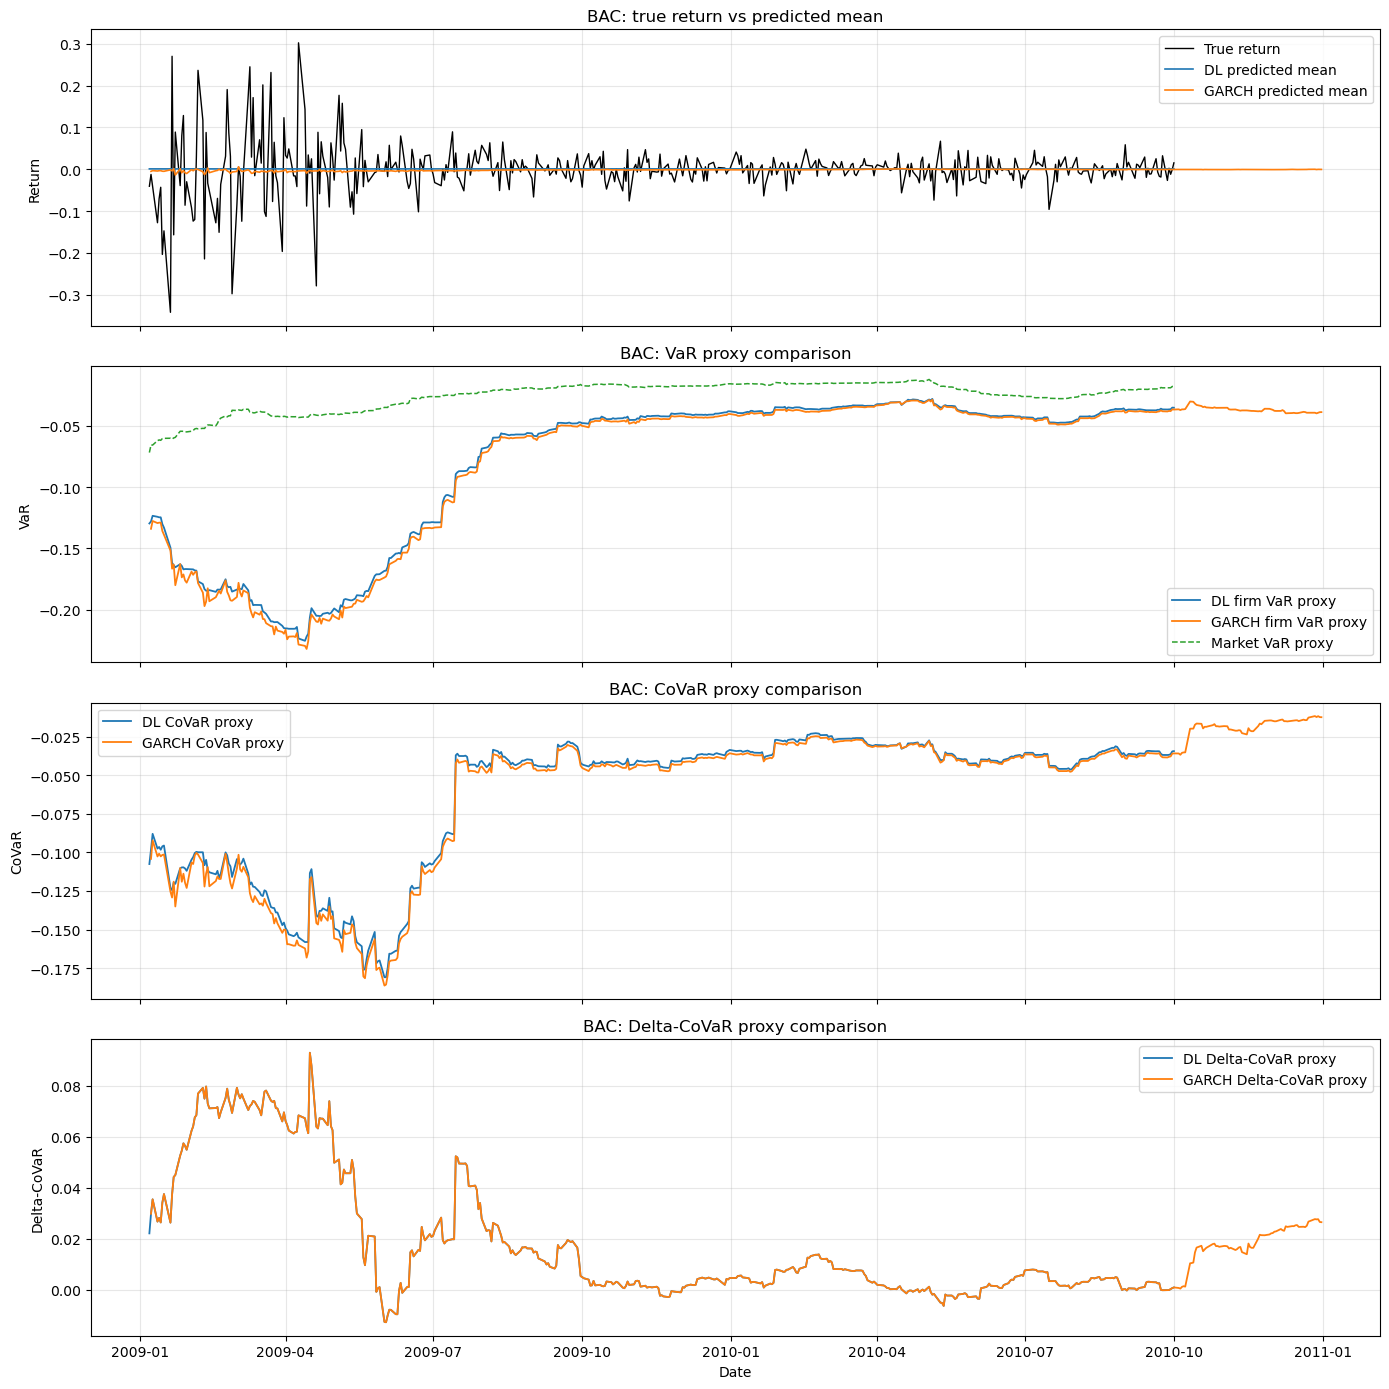

In [2]:
dl_risk, garch_risk = compare_dl_vs_garch_risk(
    dl_npz_path = "results/mamba_fred/gfc_p64.npz",
#     dl_npz_path="results/mamba2_fred_loss/inf_p64.npz",
    garch_csv_path="results/garch_preds_gfc.csv",
    eval_csv_path="dataset_finance_fred/eval/gfc_2008_2010.csv",
    ticker="BAC",
    horizon_step=1,
    q=0.05,
)

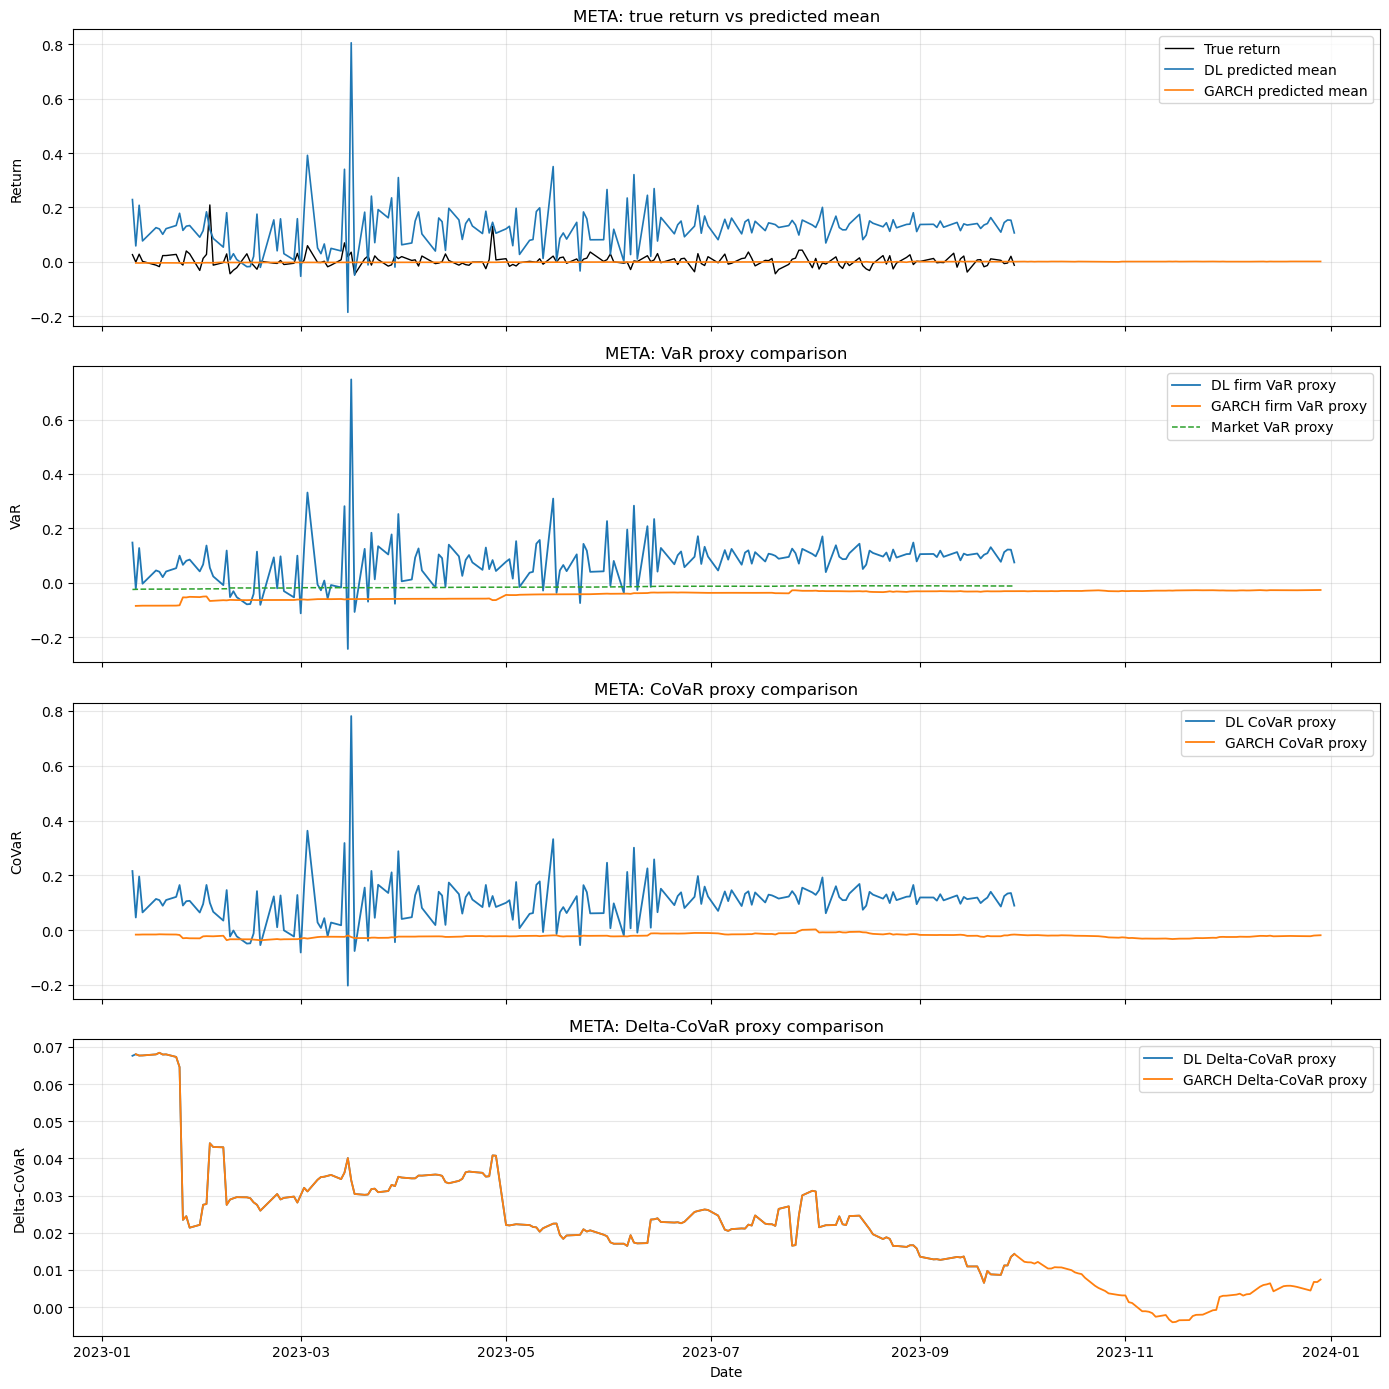

In [5]:
dl_risk, garch_risk = compare_dl_vs_garch_risk(
    # dl_npz_path = "results/inf_mamba_fred_loss_p64.npz",
    dl_npz_path="results/mamba/inf_p64.npz",
    garch_csv_path="results/garch_preds_inf.csv",
    eval_csv_path="dataset_finance_fred/eval/inflation_2022_2023.csv",
    ticker="META",
    horizon_step=1,
    q=0.05,
)

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import argparse
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm


def huber_loss(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return 0.5 * quad**2 + delta * lin


def compute_metrics(y_true, y_pred, delta=2.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = math.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    hub = np.mean(huber_loss(y_true, y_pred, delta=delta))
    sign_acc = np.mean(np.sign(y_true) == np.sign(y_pred))

    return {
        "n": int(len(y_true)),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "huber": float(hub),
        "sign_accuracy": float(sign_acc),
    }


def make_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def infer_columns(df):
    cols = list(df.columns)
    date_col = None
    for c in cols:
        if c.lower() in {"date", "datetime", "timestamp"}:
            date_col = c
            break
    if date_col is None:
        raise ValueError("Could not find date column.")

    exclude = {
        date_col,
        "market_ret_1d",
        "fed_funds",
        "rate_10y",
        "rate_2y",
        "yc_slope_10y2y",
        "cpi",
        "unemp",
        "indpro",
        "vix",
        "baa_aaa_spread",
        "dbaa",
        "daaa",
    }

    ticker_cols = [c for c in cols if c not in exclude]
    macro_cols = [c for c in cols if c in exclude and c != date_col and c != "market_ret_1d"]

    return date_col, ticker_cols, macro_cols


def build_panel_from_wide_csv(csv_path):
    df = pd.read_csv(csv_path)
    date_col, ticker_cols, macro_cols = infer_columns(df)

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    panel_rows = []

    for ticker in ticker_cols:
        tmp = pd.DataFrame({
            "date": df[date_col],
            "ticker": ticker,
            "firm_ret_t": df[ticker].astype(float),
            "market_ret_t": df["market_ret_1d"].astype(float),
        })

        for c in macro_cols:
            tmp[c] = df[c].astype(float)

        tmp["target_date"] = tmp["date"].shift(-1)
        tmp["y_next"] = tmp["firm_ret_t"].shift(-1)

        tmp = tmp.dropna(subset=["firm_ret_t", "market_ret_t", "target_date", "y_next"]).copy()
        panel_rows.append(tmp)

    panel = pd.concat(panel_rows, axis=0, ignore_index=True)
    panel = panel.sort_values(["target_date", "ticker"]).reset_index(drop=True)
    return panel


def make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    num_pipe = Pipeline(num_steps)
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot()),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, numeric_cols),
            ("cat", cat_pipe, categorical_cols),
        ],
        remainder="drop",
    )
    return pre


def make_model_specs(numeric_cols, categorical_cols):
    specs = {}

    # OLS
    specs["OLS"] = Pipeline([
        ("pre", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
        ("model", LinearRegression()),
    ])

    # PCR
    specs["PCR"] = Pipeline([
        ("pre", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
        ("pca", PCA(n_components=8)),
        ("model", LinearRegression()),
    ])

    # PLS
    specs["PLS"] = Pipeline([
        ("pre", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
        ("model", PLSRegression(n_components=6)),
    ])

    # RF
    specs["RF"] = Pipeline([
        ("pre", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=False)),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )),
    ])

    return specs


class GLMRegressor:
    def __init__(self, numeric_cols, categorical_cols):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.pre = make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)
        self.res_ = None

    def fit(self, X, y):
        Xp = self.pre.fit_transform(X)
        Xp = sm.add_constant(Xp, has_constant="add")
        self.res_ = sm.GLM(
            y,
            Xp,
            family=sm.families.Gaussian(),
        ).fit()
        return self

    def predict(self, X):
        Xp = self.pre.transform(X)
        Xp = sm.add_constant(Xp, has_constant="add")
        return self.res_.predict(Xp)


def walk_forward_panel_eval(
    panel_df,
    model_name,
    model_obj,
    feature_cols,
    warmup_dates=60,
    refit_every=20,
):
    unique_dates = np.array(sorted(panel_df["target_date"].unique()))
    if len(unique_dates) <= warmup_dates:
        raise ValueError(
            f"Not enough target dates ({len(unique_dates)}) for warmup_dates={warmup_dates}"
        )

    preds_out = []
    current_model = None

    for i in range(warmup_dates, len(unique_dates)):
        current_date = unique_dates[i]

        train_dates = unique_dates[:i]
        train_df = panel_df[panel_df["target_date"].isin(train_dates)].copy()
        test_df = panel_df[panel_df["target_date"] == current_date].copy()

        if len(test_df) == 0 or len(train_df) == 0:
            continue

        should_refit = (current_model is None) or ((i - warmup_dates) % refit_every == 0)

        if should_refit:
            X_train = train_df[feature_cols]
            y_train = train_df["y_next"].values

            if model_name == "GLM":
                current_model = GLMRegressor(
                    numeric_cols=[c for c in feature_cols if c != "ticker"],
                    categorical_cols=["ticker"],
                )
            else:
                current_model = clone(model_obj)

            current_model.fit(X_train, y_train)

        X_test = test_df[feature_cols]
        y_pred = current_model.predict(X_test)

        out = test_df[["target_date", "ticker", "y_next"]].copy()
        out["y_pred"] = np.asarray(y_pred).reshape(-1)
        out = out.rename(columns={"target_date": "date", "y_next": "y_true"})
        preds_out.append(out)

    if not preds_out:
        raise ValueError(f"No predictions produced for model {model_name}")

    pred_df = pd.concat(preds_out, axis=0, ignore_index=True)
    return pred_df


def run_all_models_on_csv(
    csv_path,
    out_dir,
    warmup_dates=60,
    refit_every=20,
    huber_delta=2.0,
):
    panel = build_panel_from_wide_csv(csv_path)

    feature_cols = [c for c in panel.columns if c not in {"date", "target_date", "y_next"}]
    numeric_cols = [c for c in feature_cols if c != "ticker"]
    categorical_cols = ["ticker"]

    specs = make_model_specs(numeric_cols, categorical_cols)
    # specs["GLM"] = None  # handled separately

    split_name = Path(csv_path).stem
    split_out = Path(out_dir) / split_name
    split_out.mkdir(parents=True, exist_ok=True)

    metrics_rows = []

    for model_name, model_obj in specs.items():
        print(f"\n=== Running {model_name} on {split_name} ===")
        pred_df = walk_forward_panel_eval(
            panel_df=panel,
            model_name=model_name,
            model_obj=model_obj,
            feature_cols=feature_cols,
            warmup_dates=warmup_dates,
            refit_every=refit_every,
        )

        metrics = compute_metrics(
            pred_df["y_true"].values,
            pred_df["y_pred"].values,
            delta=huber_delta,
        )
        metrics["model"] = model_name
        metrics["split"] = split_name
        metrics_rows.append(metrics)

        pred_path = split_out / f"{model_name.lower()}_predictions.csv"
        pred_df.to_csv(pred_path, index=False)
        print(metrics)
        print(f"Saved predictions to {pred_path}")

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_path = split_out / "metrics_summary.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print(f"\nSaved summary to {metrics_path}")

    return metrics_df



all_metrics = []
csv_files = ['dataset_finance_fred2/eval/covid_2020_2021.csv']
out_dir = 'baseline'
warmup_dates = 256
refit_every = 64
huber_delta = 2.0


for csv_path in csv_files:
    metrics_df = run_all_models_on_csv(
        csv_path=csv_path,
        out_dir=out_dir,
        warmup_dates=warmup_dates,
        refit_every=refit_every,
        huber_delta=huber_delta,
    )
    all_metrics.append(metrics_df)

all_metrics_df = pd.concat(all_metrics, axis=0, ignore_index=True)
all_metrics_path = Path(out_dir) / "all_splits_metrics_summary.csv"
all_metrics_df.to_csv(all_metrics_path, index=False)
print(f"\nSaved combined summary to {all_metrics_path}")




=== Running OLS on gfc_2008_2010 ===
{'n': 211907, 'mse': 0.0008406085572261702, 'rmse': 0.02899325020114458, 'mae': 0.01871135912745057, 'huber': 0.0004203042786130851, 'sign_accuracy': 0.5001580882179447, 'model': 'OLS', 'split': 'gfc_2008_2010'}
Saved predictions to baseline/gfc_2008_2010/ols_predictions.csv

=== Running PCR on gfc_2008_2010 ===
{'n': 211907, 'mse': 0.0007992123418823842, 'rmse': 0.02827034385858057, 'mae': 0.018235291101359557, 'huber': 0.0003996061709411921, 'sign_accuracy': 0.4947736507052622, 'model': 'PCR', 'split': 'gfc_2008_2010'}
Saved predictions to baseline/gfc_2008_2010/pcr_predictions.csv

=== Running PLS on gfc_2008_2010 ===
{'n': 211907, 'mse': 0.0008429045775287938, 'rmse': 0.02903281897316886, 'mae': 0.018760604313520324, 'huber': 0.0004214522887643969, 'sign_accuracy': 0.5012765033717621, 'model': 'PLS', 'split': 'gfc_2008_2010'}
Saved predictions to baseline/gfc_2008_2010/pls_predictions.csv

=== Running RF on gfc_2008_2010 ===
{'n': 211907, 'mse'

: 